<a href="https://colab.research.google.com/github/nomanabdullah04/ML_Project_TestsYour_Math_Score/blob/main/Model_Traning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Import basic libary***

In [112]:
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#modelng
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error # Only regression metrics

# Regression Models - replaced all classifiers with regressors
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV

**Import the CSV Data as Pandas DataFrame**

In [93]:
df=pd.read_csv('/content/StudentsPerformance.csv')

In [94]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [95]:
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [96]:
df.nunique()


,0
gender,2
race/ethnicity,5
parental level of education,6
lunch,2
test preparation course,2
math score,81
reading score,72
writing score,77


In [97]:
#Check duplicates
df.duplicated().sum()
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [98]:
#Exploring Data
print("Categorical is 'gender' vaaribale:  ",end=" ")
print(df['gender'].unique())
print("Categorical is 'race/ethnicity' vaaribale:  ",end=" ")
print(df['race/ethnicity'].unique())
print("Categorical is 'parental level of education' vaaribale:  ",end=" ")
print(df['parental level of education'].unique())
print("Categorical is 'lunch' vaaribale:  ",end=" ")
print(df['lunch'].unique())
print("Categorical is 'test preparation course' vaaribale:  ",end=" ")
print(df['test preparation course'].unique())


Categorical is 'gender' vaaribale:   ['female' 'male']
Categorical is 'race/ethnicity' vaaribale:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categorical is 'parental level of education' vaaribale:   ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categorical is 'lunch' vaaribale:   ['standard' 'free/reduced']
Categorical is 'test preparation course' vaaribale:   ['none' 'completed']


In [99]:
#Deterdeine the categorical and Numerical Column
numerical_features=[feature for feature in df.columns if df[feature].dtype!='O']
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O']

In [100]:
#Adding ccolumns for total score
df['Total_Score']=df['math score']+df['reading score']+df['writing score']
df['Average_Score']=df['Total_Score']/3
df['Average_Score']=df['Average_Score'].round(2)

In [101]:
#preparing x and y variables
x=df.drop(columns=['math score'],axis=1)
y=df['math score']

In [102]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_Score,Average_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67
1,female,group C,some college,standard,completed,69,90,88,247,82.33
2,female,group B,master's degree,standard,none,90,95,93,278,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33
4,male,group C,some college,standard,none,76,78,75,229,76.33


In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#Create colums transformer with 3 types of transformers

# Define 'x' dataframe - assuming 'df' is your main dataframe for features
# If you have a target variable 'y', you should define 'x' as df.drop('your_target_column', axis=1)
x = df.copy()

# Redefine features based on 'x' dataframe to ensure consistency
numerical_features=[feature for feature in x.columns if x[feature].dtype!='O']
categorical_features=[feature for feature in x.columns if x[feature].dtype=='O']

print(f"Numerical Features for ColumnTransformer: {numerical_features}")
print(f"Categorical Features for ColumnTransformer: {categorical_features}")

numerical_transformer=StandardScaler()
categorical_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ('OneHotEncoder',categorical_transformer,categorical_features),
        ('StandardScaler',numerical_transformer,numerical_features)
    ]
)

Numerical Features for ColumnTransformer: ['math score', 'reading score', 'writing score', 'Total_Score', 'Average_Score']
Categorical Features for ColumnTransformer: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [104]:
x=preprocessor.fit_transform(x)

In [105]:
x

array([[ 1.        ,  0.        ,  0.        , ...,  0.39149181,
         0.34357423,  0.3438146 ],
       [ 1.        ,  0.        ,  0.        , ...,  1.31326868,
         1.0219275 ,  1.02170075],
       [ 1.        ,  0.        ,  0.        , ...,  1.64247471,
         1.74706375,  1.7473056 ],
       ...,
       [ 1.        ,  0.        ,  0.        , ..., -0.20107904,
        -0.19443008, -0.19442421],
       [ 1.        ,  0.        ,  0.        , ...,  0.58901542,
         0.46053169,  0.46030435],
       [ 1.        ,  0.        ,  0.        , ...,  1.18158627,
         1.06871048,  1.0687177 ]])

In [106]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_Score,Average_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67
1,female,group C,some college,standard,completed,69,90,88,247,82.33
2,female,group B,master's degree,standard,none,90,95,93,278,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33
4,male,group C,some college,standard,none,76,78,75,229,76.33


In [107]:
x.shape

(1000, 22)

In [108]:
#seperate dataset into train and test
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape

((800, 22), (200, 22))

**Create an Evulate function to give all matrics after model traning**

In [109]:
def evaluate_model(true,predicted):
  mae=mean_absolute_error(true,predicted)
  mse=mean_squared_error(true,predicted)
  rmse=np.sqrt(mean_squared_error(true,predicted))
  r2_square=r2_score(true,predicted)
  return mae,mse,rmse,r2_square

In [115]:
models={
    'LinearRegression': LinearRegression(), # Added Linear Regression
    'Ridge':Ridge(),
    'Lasso':Lasso(), # Corrected typo from 'lesso' to 'Lasso'
    'ElasticNet':ElasticNet(),
    'DecisionTreeRegressor':DecisionTreeRegressor(), # Changed to Regressor
    'RandomForestRegressor':RandomForestRegressor(), # Changed to Regressor
    'AdaBoostRegressor':AdaBoostRegressor(), # Changed to Regressor
    'GradientBoostingRegressor':GradientBoostingRegressor(), # Added Regressor
    'BaggingRegressor':BaggingRegressor(), # Added Regressor
    'KNeighborsRegressor':KNeighborsRegressor(), # Changed to Regressor
    'SVR':SVR(), # Changed to Regressor
    'CatBoostRegressor':CatBoostRegressor(verbose=False), # Changed to Regressor
    'XGBRegressor':XGBRegressor(), # Changed to Regressor
    'LGBMRegressor':LGBMRegressor() # Added Regressor
    # Removed all other classification-only models
}
model_list=[]
r2_list=[]

for i in range(len(list(models))):
  model=list(models.values())[i]
  model_name=list(models.keys())[i] # Get model name for logging
  print(f"Training {model_name}...") # Added print for progress

  model.fit(x_train,y_train)  # Training models
  y_train_pred=model.predict(x_train)
  y_test_pred=model.predict(x_test)

  # Evaluate train and test dataset - updated to regression metrics only
  model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train,y_train_pred)
  model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test,y_test_pred)

  print(f"{model_name}")
  print('Model performance for Training set')
  print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
  print("- Mean Squared Error: {:.4f}".format(model_train_mse))
  print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
  print("- R2 Score: {:.4f}".format(model_train_r2))
  print('----------------------------------')
  print('Model performance for Test set')
  print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
  print("- Mean Squared Error: {:.4f}".format(model_test_mse))
  print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
  print("- R2 Score: {:.4f}".format(model_test_r2))
  model_list.append(model_name) # Added this line back to append model name
  r2_list.append(model_test_r2) # Storing test R2 score
  print('='*35)
  print('\n')

Training LinearRegression...
LinearRegression
Model performance for Training set
- Root Mean Squared Error: 0.0000
- Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.0000
- Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000


Training Ridge...
Ridge
Model performance for Training set
- Root Mean Squared Error: 0.0525
- Mean Squared Error: 0.0028
- Mean Absolute Error: 0.0421
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.0532
- Mean Squared Error: 0.0028
- Mean Absolute Error: 0.0416
- R2 Score: 1.0000


Training Lasso...
Lasso
Model performance for Training set
- Root Mean Squared Error: 1.0094
- Mean Squared Error: 1.0188
- Mean Absolute Error: 0.8032
- R2 Score: 0.9955
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1.0575
- Mea

**Results**

In [116]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
0,LinearRegression,1.000000
1,Ridge,0.999988
7,GradientBoostingRegressor,0.998604
4,DecisionTreeRegressor,0.998500
12,XGBRegressor,0.998467
2,Lasso,0.995404
5,RandomForestRegressor,0.995384
8,BaggingRegressor,0.995015
11,CatBoostRegressor,0.993998
6,AdaBoostRegressor,0.987736


# **Linear Regression**

In [117]:
lin_model=LinearRegression()
lin_model.fit(x_train,y_train)
y_pred=lin_model.predict(x_test)
score=r2_score(y_test,y_pred)*100
print("R2 score of the model is %.2f" %score)

R2 score of the model is 100.00


Text(0, 0.5, 'Predicted')

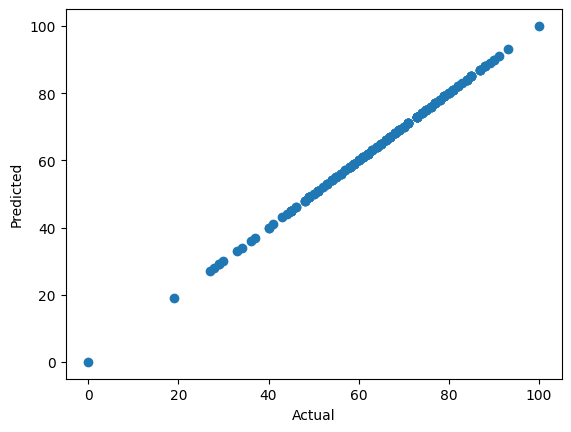

In [118]:
#plot y_pred and y_test
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math score'>

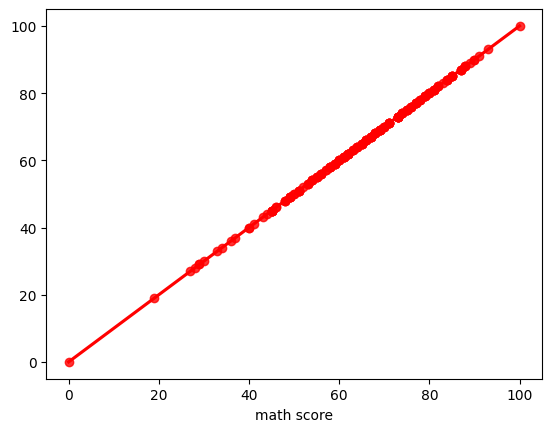

In [119]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

# **Differenece Between Actula and predict value**

In [120]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,91.0,-2.131628e-13
737,53,53.0,4.263256e-14
740,80,80.0,-5.684342e-14
660,74,74.0,-5.684342e-14
411,84,84.0,-1.278977e-13
...,...,...,...
408,52,52.0,1.278977e-13
332,62,62.0,1.136868e-13
208,74,74.0,-8.526513e-14
613,65,65.0,-4.263256e-14
